## Importation des bibliothèques

In [62]:
import pandas as pd
import numpy as np
import networkx as nx
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from google.colab import drive

## Chargement des données

In [39]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Load the latest version
network = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "sergionefedov/fraud-detection-1m-transactions-7-fraud-types",
  "network_edges.csv",
)

transaction = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "sergionefedov/fraud-detection-1m-transactions-7-fraud-types",
  "transactions.csv",
)

/tmp/ipykernel_967/1315333833.py:7: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  network = kagglehub.load_dataset(


Using Colab cache for faster access to the 'fraud-detection-1m-transactions-7-fraud-types' dataset.


/tmp/ipykernel_967/1315333833.py:13: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  transaction = kagglehub.load_dataset(


Using Colab cache for faster access to the 'fraud-detection-1m-transactions-7-fraud-types' dataset.


In [40]:
network.head()

,account_a,account_b,shared_type,connection_count,ring_id,both_fraud
0,ACC0017803,ACC0040032,phone,7,RING0001,1
1,ACC0017803,ACC0042246,email_domain,12,RING0001,1
2,ACC0017803,ACC0029491,phone,13,RING0001,1
3,ACC0017803,ACC0022213,phone,12,RING0001,1
4,ACC0017803,ACC0007601,ip_address,14,RING0001,1


In [41]:
network.shape

(7411, 6)

## Features agrégées par compte

In [42]:
account_features = transaction.groupby('account_id').agg(
    nb_transactions = ('transaction_id', 'count'),
    taux_fraude = ('is_fraud', 'mean'),
    montant_moyen = ('amount', 'mean'),
    velocity_moy = ('velocity_1h', 'mean'),
    ip_risk_moy = ('ip_risk_score', 'mean'),
    nb_pays = ('merchant_country', 'nunique'),
    a_fraud_pattern = ('fraud_pattern', lambda x: int(x.notna().any()))
).reset_index()

In [43]:
account_features.head()

,account_id,nb_transactions,taux_fraude,montant_moyen,velocity_moy,ip_risk_moy,nb_pays,a_fraud_pattern
0,ACC0000001,49,0.0,147.889796,1.265306,22.983673,9,0
1,ACC0000002,2,0.5,140.395000,4.000000,52.450000,2,1
2,ACC0000003,18,0.0,246.427222,1.444444,15.500000,3,0
3,ACC0000004,18,0.0,323.582222,1.111111,19.005556,4,0
4,ACC0000005,19,0.0,202.618421,0.947368,26.710526,7,0


## Construction du graphe

In [44]:
graph = nx.from_pandas_edgelist(
    network,
    source='account_a',
    target='account_b',
    edge_attr=['shared_type', 'connection_count', 'ring_id', 'both_fraud']
)

In [45]:
# Degré de chaque noeud
degree_dict = dict(graph.degree())

# Taille de chaque anneau
ring_sizes = network[network['ring_id'].notna()].groupby('ring_id').apply(
    lambda x: len(set(x['account_a'].tolist() + x['account_b'].tolist()))
).to_dict()

print(f"Graphe construit :")
print(f"   Noeuds : {graph.number_of_nodes()}")
print(f"   Arêtes : {graph.number_of_edges()}")
print(f"   Anneaux frauduleux : {network['ring_id'].nunique()}")

Graphe construit :
   Noeuds : 6783
   Arêtes : 7411
   Anneaux frauduleux : 200


/tmp/ipykernel_967/4034463280.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ring_sizes = network[network['ring_id'].notna()].groupby('ring_id').apply(


## Construction du dataset

In [46]:
df = network.copy()

# Features du lien
df["fait_part_ring"] = network["ring_id"].notna()
df["taille_ring"] = network["ring_id"].map(ring_sizes).fillna(0)

# Feature du compte A
df = df.merge(
    account_features.rename(
        columns={
            col : f"{col}_a" for col in account_features.columns if col != 'account_id'
        }
    ),
    left_on="account_a",
    right_on="account_id",
    how="left"
).drop(columns="account_id")

df = df.merge(
    account_features.rename(
        columns={
            col : f"{col}_b" for col in account_features.columns if col != 'account_id'
        }
    ),
    left_on="account_b",
    right_on="account_id",
    how="left"
).drop(columns="account_id")

In [47]:
# Features d'intéraction entre A et B
df['diff_taux_fraud'] = abs(df["taux_fraude_a"] - df["taux_fraude_b"])
df["diff_montant"] = abs(df["montant_moyen_a"] - df["montant_moyen_b"])
df["diff_ip_risk"] = abs(df["ip_risk_moy_a"] - df["ip_risk_moy_b"])
df["som_taux_fraude"] = df["taux_fraude_a"] + df["taux_fraude_b"]

# Dégré dans le graphe
df["degre_a"] = df["account_a"].map(degree_dict).fillna(0)
df["degre_b"] = df["account_b"].map(degree_dict).fillna(0)

In [48]:
print(f"Dimension du dataset : {df.shape}")
df.head()

Dimension du dataset : (7411, 28)


,account_a,account_b,shared_type,connection_count,ring_id,both_fraud,fait_part_ring,taille_ring,nb_transactions_a,taux_fraude_a,...,velocity_moy_b,ip_risk_moy_b,nb_pays_b,a_fraud_pattern_b,diff_taux_fraud,diff_montant,diff_ip_risk,som_taux_fraude,degre_a,degre_b
0,ACC0017803,ACC0040032,phone,7,RING0001,1,True,6.0,43,0.046512,...,0.592593,22.896296,6,1,0.009475,88.108372,0.003273,0.083549,5,13
1,ACC0017803,ACC0042246,email_domain,12,RING0001,1,True,6.0,43,0.046512,...,1.297297,18.437838,8,1,0.007542,106.778102,4.455185,0.100566,5,5
2,ACC0017803,ACC0029491,phone,13,RING0001,1,True,6.0,43,0.046512,...,0.631579,23.294737,5,1,0.006120,33.179425,0.401714,0.099143,5,5
3,ACC0017803,ACC0022213,phone,12,RING0001,1,True,6.0,43,0.046512,...,1.074074,20.629630,7,1,0.009475,17.833557,2.263394,0.083549,5,5
4,ACC0017803,ACC0007601,ip_address,14,RING0001,1,True,6.0,43,0.046512,...,0.954545,23.054545,8,1,0.001057,80.686099,0.161522,0.091966,5,5


In [49]:
# La variable cible
df['is_fraud_connection'] = (
    (df['ring_id'].notna()) & (df['both_fraud'] == 1)
).astype(int)

y_network = df['is_fraud_connection'].values

In [50]:
print(f"\nDistribution du label :")
print(f"   Connexions frauduleuses  : {y_network.sum()} ({y_network.mean()*100:.1f}%)")
print(f"   Connexions légitimes     : {(y_network == 0).sum()} ({(1-y_network.mean())*100:.1f}%)")


Distribution du label :
   Connexions frauduleuses  : 4411 (59.5%)
   Connexions légitimes     : 3000 (40.5%)


In [51]:
col_supprimer = [
    "account_a",
    "account_b",
    "ring_id",
    "both_fraud",
    "is_fraud_connection"
]

df = df.drop(columns = col_supprimer)

## Encodage

In [53]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
shared_type = encoder.fit_transform(df[["shared_type"]])

df = df.drop(columns=["shared_type"])

X_network = np.hstack([
    df.values.astype(float),
    shared_type
])

## Normalisation


In [54]:
scaler = StandardScaler()
X_network_scaled = scaler.fit_transform(X_network)

## Sauvegarde

In [56]:
drive.mount("/content/drive")

Mounted at /content/drive


In [61]:
data_dir = "/content/drive/MyDrive/fraud_detection/data"
models_dir = "/content/drive/MyDrive/fraud_detection/models"
os.makedirs(data_dir, exist_ok=True)
os.makedirs(models_dir, exist_ok=True)

np.save(f"{data_dir}/X_network_scaled.npy", X_network_scaled)
np.save(f"{data_dir}/y_network.npy", y_network)

with open(f"{models_dir}/encoder_network.pkl", 'wb') as f:
    pickle.dump(encoder, f)
with open(f"{models_dir}/scaler_network.pkl", 'wb') as f:
    pickle.dump(scaler, f)

## Modélisation

In [63]:
X = X_network_scaled
y = y_network

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [65]:
n_legitime = (y_train == 0).sum()
n_fraude   = (y_train == 1).sum()
scale_pos_weight = n_legitime / n_fraude

model_network = XGBClassifier(
    n_estimators      = 300,
    max_depth         = 6,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = scale_pos_weight,
    use_label_encoder = False,
    eval_metric       = 'auc',
    random_state      = 42
)

## Entrainement

In [66]:

model_network.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:51:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[0]	validation_0-auc:1.00000
[50]	validation_0-auc:1.00000
[100]	validation_0-auc:1.00000
[150]	validation_0-auc:1.00000
[200]	validation_0-auc:1.00000
[250]	validation_0-auc:1.00000
[299]	validation_0-auc:1.00000


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

## Evaluation

In [67]:
y_pred = model_network.predict(X_test)
y_pred_proba = model_network.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)

In [68]:
print("\n ----------- Rapport de Classification ------------ \n\n")
print(classification_report(y_test, y_pred,
      target_names=['Légitime', 'Frauduleuse']))
print(f"AUC-ROC : {auc:.4f}")


 ----------- Rapport de Classification ------------ 


              precision    recall  f1-score   support

    Légitime       1.00      1.00      1.00       600
 Frauduleuse       1.00      1.00      1.00       883

    accuracy                           1.00      1483
   macro avg       1.00      1.00      1.00      1483
weighted avg       1.00      1.00      1.00      1483

AUC-ROC : 1.0000


## Visualisation

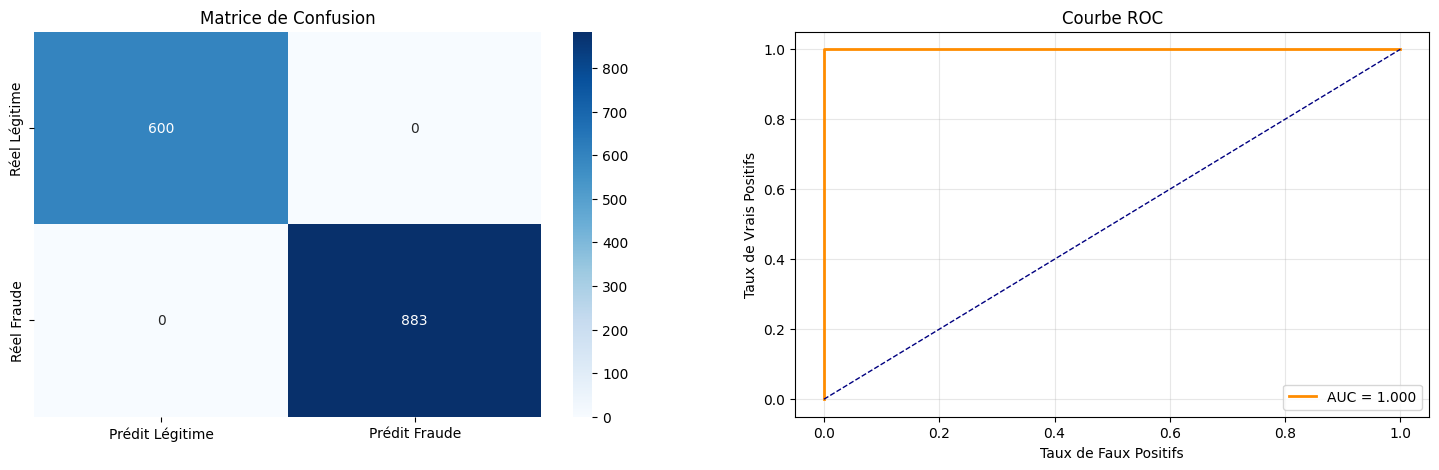

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# --- Matrice de confusion ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prédit Légitime', 'Prédit Fraude'],
            yticklabels=['Réel Légitime', 'Réel Fraude'],
            ax=axes[0])
axes[0].set_title('Matrice de Confusion')

# --- Courbe ROC ---
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
axes[1].set_xlabel('Taux de Faux Positifs')
axes[1].set_ylabel('Taux de Vrais Positifs')
axes[1].set_title('Courbe ROC')
axes[1].legend()
axes[1].grid(alpha=0.3)

## Sauvegarde du modèle

In [72]:
with open(f"{models_dir}/network_model.pkl", "wb") as file:
  pickle.dump(model_network, file)